# non-parametric Locally Weighted Regression algorithm 

In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np

In [6]:
data = pd.read_csv('tips.csv') 
bill = np.array(data.total_bill) 
tip = np.array(data.tip) 

In [12]:
def kernel(point, xmat, k):
    m, n = np.shape(xmat)
    weights = np.asmatrix(np.eye(m))

    for j in range(m):
        diff = point - X[j]
        value = (diff * diff.T).item()
        weights[j, j] = np.exp(value / (-2.0 * k**2))

    return weights


def localWeight(point, xmat, ymat, k):
    wei = kernel(point, xmat, k)
    W = (X.T * (wei * X)).I * (X.T * (wei * ymat.T))
    return W


def localWeightRegression(xmat, ymat, k):
    m, n = np.shape(xmat)
    ypred = np.zeros(m)

    for i in range(m):
        value = (xmat[i] * localWeight(xmat[i], xmat, ymat, k)).item()
        ypred[i] = value

    return ypred

In [15]:
mbill = np.asmatrix(bill)
mtip = np.asmatrix(tip)

m = np.shape(mbill)[1]

one = np.asmatrix(np.ones(m))

X = np.hstack((one.T, mbill.T))

ypred = localWeightRegression(X, mtip, 0.5)

SortIndex = np.argsort(np.asarray(X[:, 1]).ravel())

xsort = np.asarray(X)[SortIndex]

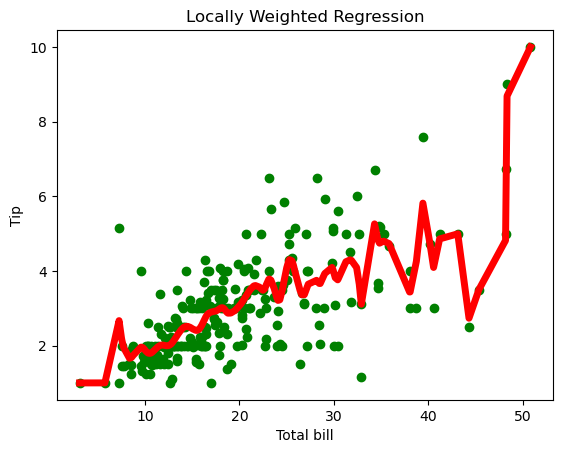

In [16]:
import matplotlib.pyplot as plt

fig = plt.figure()

ax = fig.add_subplot(1, 1, 1)

ax.scatter(bill, tip, color='green')

ax.plot(
    xsort[:, 1],
    ypred[SortIndex],
    color='red',
    linewidth=5
)

plt.xlabel('Total bill')
plt.ylabel('Tip')
plt.title('Locally Weighted Regression')

plt.show()